In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("data/train-test.csv")
df.sample(5)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
35854,TR-035855,Madison,Toledo,41.70243,-89.85588,41.97663,-84.45902,338.7,Reefer,42410.0,2025-08-14,1.06307,1.65569,878.84
12858,TR-012859,Milwaukee,Mobile,39.62180,-88.48008,31.80442,-88.25195,639.1,Reefer,27592.0,2025-03-23,0.97320,2.40818,1564.01
28963,TR-028964,Savannah,Fort Wayne,33.60973,-82.29994,41.31561,-85.36206,668.0,Flatbed,35063.0,2025-07-02,1.35941,1.75841,1587.61
10895,TR-010896,Washington,Phoenix,38.87577,-77.05086,28.75668,-115.87725,2662.1,Dry Van,22026.0,2025-03-11,1.08222,1.69827,4525.26
38814,TR-038815,Baton Rouge,Jacksonville,30.50134,-92.65374,31.98691,-84.48897,595.5,Dry Van,27648.0,2025-09-03,1.00055,2.18555,1311.58


In [11]:
# Since load_id is not an useful column for our dataset we can remove it safely.
df = df.drop(columns=['load_id'])

In [12]:
df.shape

(48000, 13)

In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pickup        48000 non-null  str    
 1   delivery      48000 non-null  str    
 2   pickup_lat    48000 non-null  float64
 3   pickup_lon    48000 non-null  float64
 4   delivery_lat  48000 non-null  float64
 5   delivery_lon  48000 non-null  float64
 6   distance      48000 non-null  float64
 7   equipment     48000 non-null  str    
 8   weight        47700 non-null  float64
 9   date          48000 non-null  str    
 10  market_index  47626 non-null  float64
 11  quote_signal  48000 non-null  float64
 12  posted_rate   48000 non-null  float64
dtypes: float64(9), str(4)
memory usage: 4.8 MB


In [14]:
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

Memory usage: 14.52 MB


I don't think I need to type cast the coordinate columns into another data type because float64 stores location more accurately. However, type casting distance and weight is a good idea since they won't lose information.

In [15]:
dtypes = {
    "weight": "float32",  
    "distance": "float32",    
       
}

df = df.astype(dtypes)

print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

pickup              str
delivery            str
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float32
equipment           str
weight          float32
date                str
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

Memory usage: 14.14 MB


minimal memory impact given the small overall dataset size.

# EDA

In [8]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


There are some issues in the dataset 

1. Minimum weight is negative.

Observation 
-> The data is unrealistic because baseline quote signal yields economically unviable low prices (such as $57 for 70 miles). Which suggest that it is synthetically generated dataset.

In [17]:
df.isna().sum()

pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [21]:
df[df['weight'].isnull()].sample(5)

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
46685,Birmingham,Nashville,33.45794,-86.72789,35.29479,-88.08915,197.199997,Dry Van,NaN,2025-10-23,1.07978,1.35485,546.54
12328,Grand Rapids,Lexington,43.43800,-86.29173,36.99152,-84.99876,541.700012,Dry Van,NaN,2025-03-20,1.24101,2.11388,1145.68
26896,Dayton,Tucson,39.87206,-85.62931,30.92733,-113.23037,1918.400024,Dry Van,NaN,2025-06-19,1.38242,1.92452,3641.23
5584,Phoenix,Lubbock,28.75668,-115.87725,29.87534,-99.85456,1144.800049,Flatbed,NaN,2025-02-05,1.04300,2.11806,2432.22
39724,Charleston,Mobile,34.15334,-79.74475,31.80442,-88.25195,636.900024,Dry Van,NaN,2025-09-08,0.80556,2.16685,1357.32


In [22]:
df[df['market_index'].isnull()].sample(5)

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
1274,Little Rock,Jacksonville,34.27518,-92.06214,31.98691,-84.48897,573.400024,Dry Van,23277.0,2025-01-08,NaN,2.06009,1186.43
19568,Greensboro,Madison,35.98195,-82.78379,41.70243,-89.85588,680.000000,Flatbed,29921.0,2025-05-03,NaN,1.84806,1541.90
1787,Charleston,Bakersfield,34.15334,-79.74475,33.28832,-116.67935,2462.699951,Flatbed,16160.0,2025-01-12,NaN,1.84140,4468.86
1568,Jacksonville,Grand Rapids,31.98691,-84.48897,43.43800,-86.29173,955.900024,Dry Van,32175.0,2025-01-10,NaN,1.97149,1857.36
28856,Shreveport,Nashville,32.54628,-92.31888,35.29479,-88.08915,373.899994,Dry Van,27073.0,2025-07-01,NaN,1.73158,914.78


I will create different versions of the data: I will use the standard missingness indicator technique for training non-tree-based algorithms and leave the NaNs as they are for tree-based models.

In [31]:
for col in df.columns:
    vc = df[col].value_counts()
    print(vc)

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
                 ... 
Detroit           337
Washington        337
St. Louis         318
Las Vegas         277
Dallas            276
Name: count, Length: 64, dtype: int64
delivery
Lexington      1197
Fort Wayne     1176
Baton Rouge    1167
Bakersfield    1156
Hartford       1143
               ... 
St. Louis       344
Birmingham      318
Detroit         307
Dallas          306
Las Vegas       292
Name: count, Length: 64, dtype: int64
pickup_lat
31.88294    1242
36.99152    1209
33.28832    1193
41.31561    1170
39.55328    1150
            ... 
43.61923     337
38.87577     337
38.38204     318
33.22353     277
31.83025     276
Name: count, Length: 64, dtype: int64
pickup_lon
-98.58097     1242
-84.99876     1209
-116.67935    1193
-85.36206     1170
-72.18051     1150
              ... 
-84.04517      337
-77.05086      337
-89.88819      318
-115.24994     277
-94.38343

pickup ---------->
pickup--> has 64 unique elements


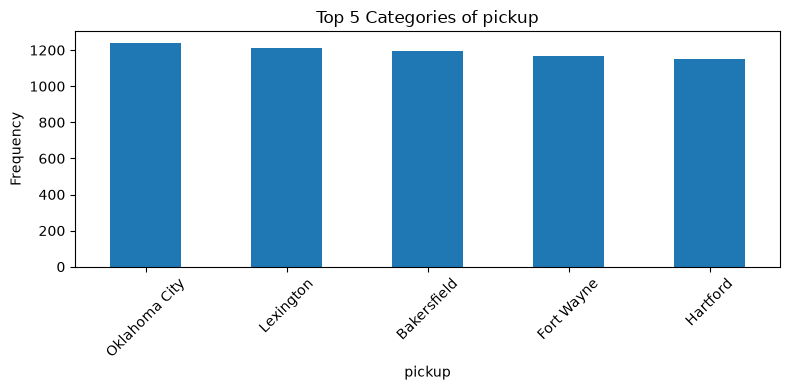

delivery ---------->
delivery--> has 64 unique elements


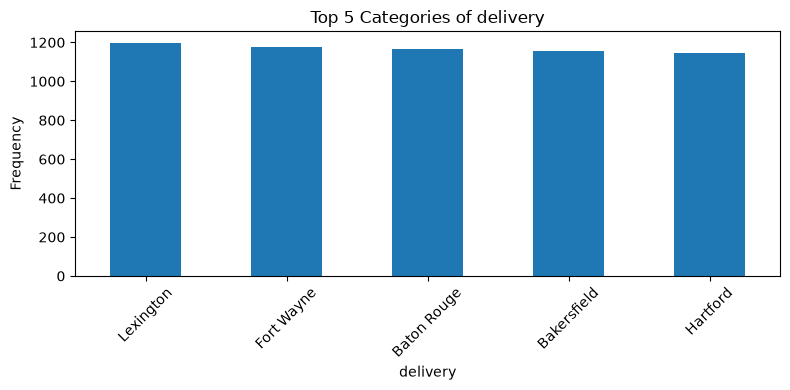

pickup_lat ---------->
pickup_lat--> has 64 unique elements


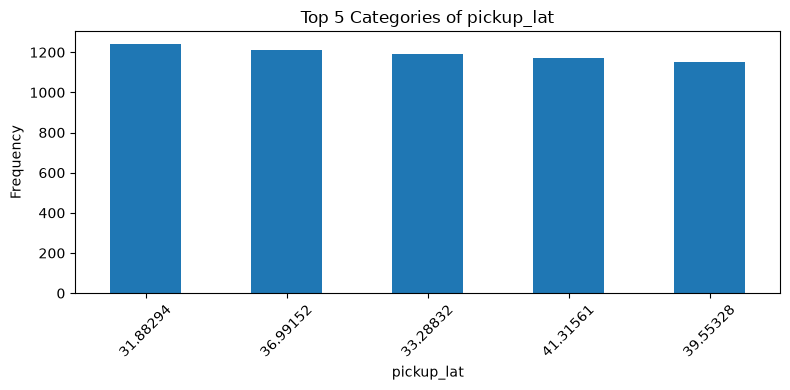

pickup_lon ---------->
pickup_lon--> has 63 unique elements


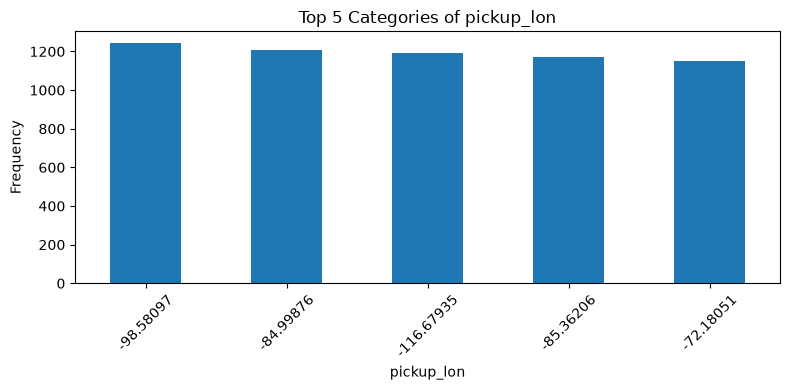

delivery_lat ---------->
delivery_lat--> has 64 unique elements


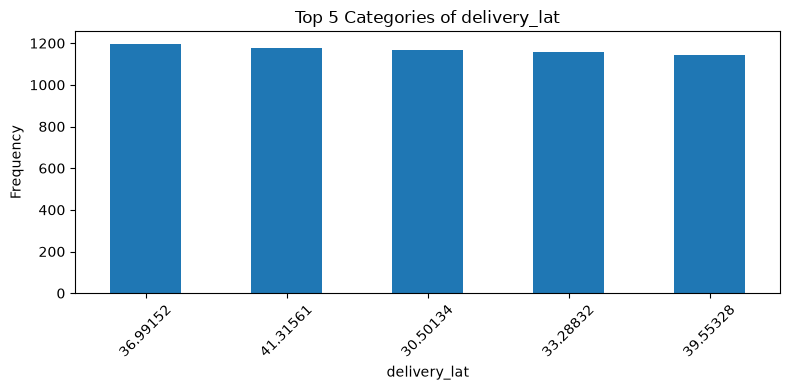

delivery_lon ---------->
delivery_lon--> has 63 unique elements


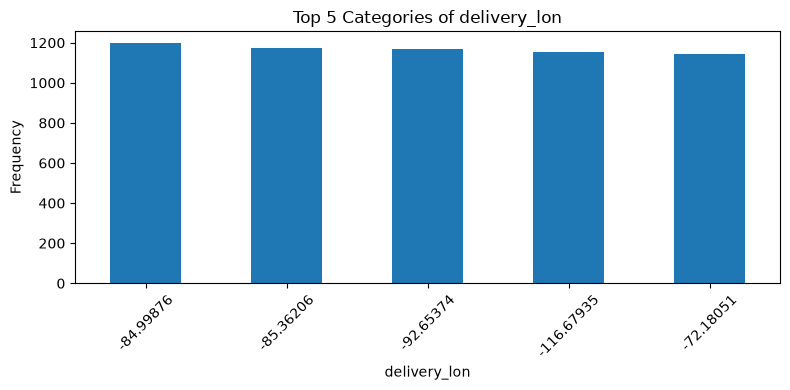

distance ---------->
distance--> has 21204 unique elements


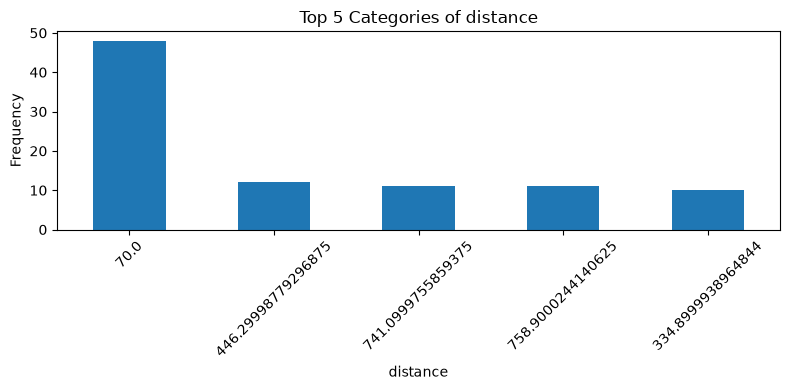

equipment ---------->
equipment--> has 3 unique elements


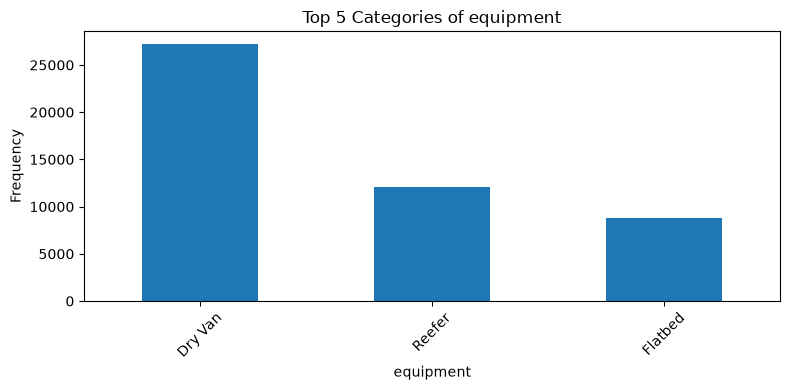

weight ---------->
weight--> has 23678 unique elements


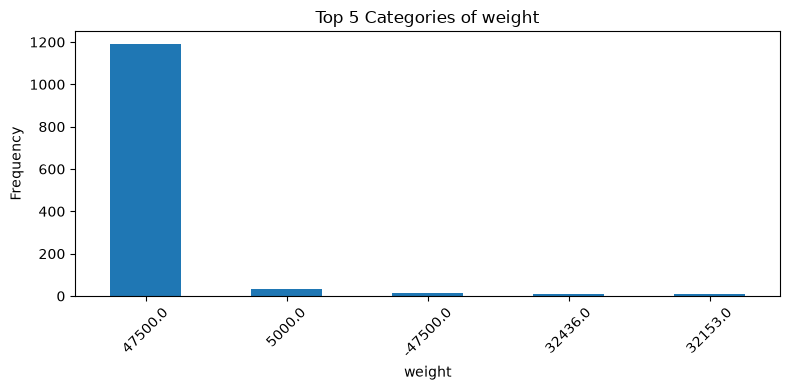

date ---------->
date--> has 304 unique elements


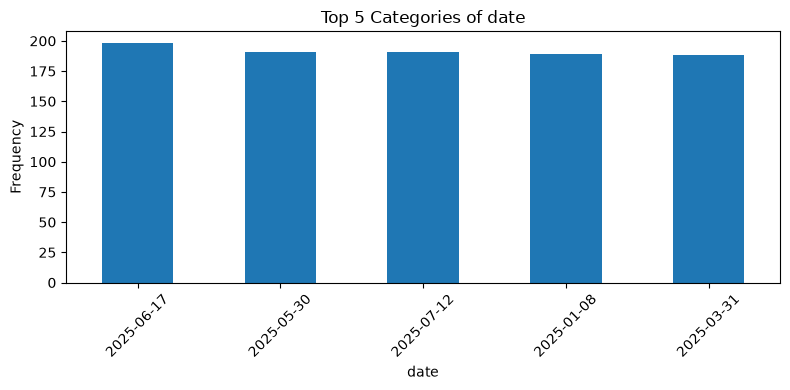

market_index ---------->
market_index--> has 32884 unique elements


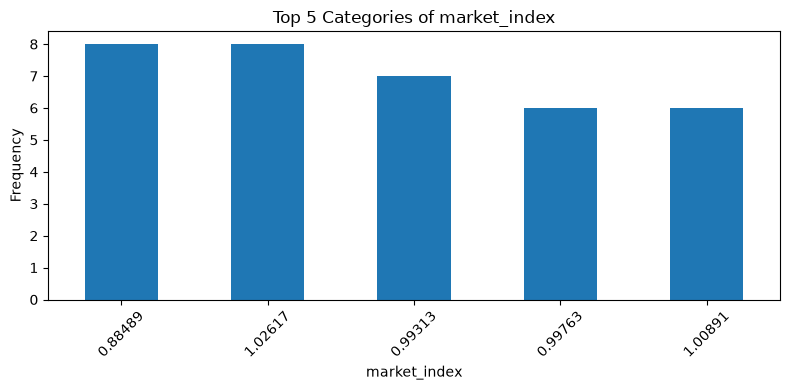

quote_signal ---------->
quote_signal--> has 37633 unique elements


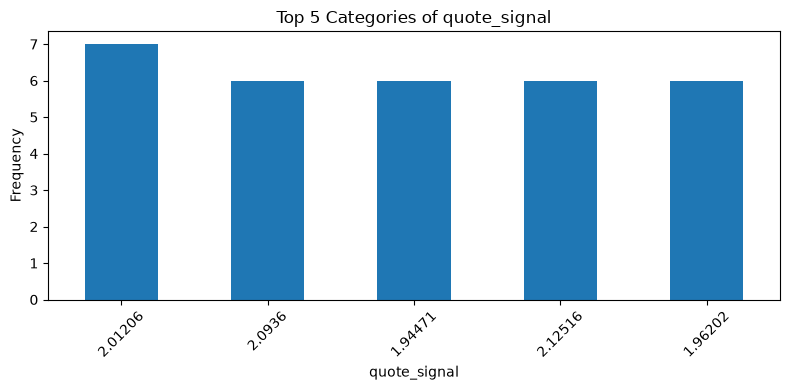

posted_rate ---------->
posted_rate--> has 45398 unique elements


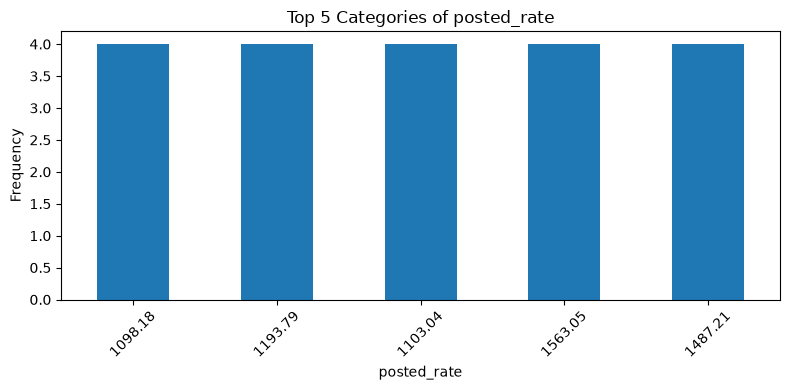

In [25]:
for col in df.columns:
    print(col + " ---------->")
    
    vc = df[col].value_counts().head(5)
    vc.plot(kind="bar", figsize=(8,4))
    
    print(f'{col}--> has {df[col].nunique()} unique elements')

    plt.title(f"Top 5 Categories of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The dataset looks as expected other than the weight column.

In [28]:
df[df['weight']==-47500]

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
5034,San Antonio,Tucson,29.50969,-98.40059,30.92733,-113.23037,1053.500000,Dry Van,-47500.0,2025-02-01,0.92422,2.05123,2178.09
5236,Oklahoma City,Baton Rouge,31.88294,-98.58097,30.50134,-92.65374,459.100006,Reefer,-47500.0,2025-02-02,0.84248,2.64037,1207.21
12591,Los Angeles,Richmond,28.56624,-116.70249,38.09122,-76.78906,2749.000000,Reefer,-47500.0,2025-03-21,1.13917,2.10986,5741.43
13620,Fort Wayne,Philadelphia,41.31561,-85.36206,39.22317,-72.96710,789.200012,Dry Van,-47500.0,2025-03-28,1.18692,2.17532,1704.51
16823,Madison,Green Bay,41.70243,-89.85588,44.30296,-87.52871,273.100006,Dry Van,-47500.0,2025-04-16,1.29884,1.67887,676.06
18064,Green Bay,Kansas City,44.30296,-87.52871,39.41104,-91.12450,475.399994,Flatbed,-47500.0,2025-04-24,1.38826,1.61000,1203.67
18488,Syracuse,Phoenix,42.80915,-76.89973,28.75668,-115.87725,2760.800049,Flatbed,-47500.0,2025-04-27,1.16860,2.14330,5478.31
20576,Montgomery,Amarillo,31.37602,-86.10743,33.17137,-104.36789,1265.599976,Flatbed,-47500.0,2025-05-10,1.29040,1.79297,2919.39
22422,Amarillo,San Francisco,33.17137,-104.36789,35.19670,-121.69849,1185.800049,Dry Van,-47500.0,2025-05-22,1.37498,2.03384,2539.75
26026,Charleston,Baton Rouge,34.15334,-79.74475,30.50134,-92.65374,934.900024,Dry Van,-47500.0,2025-06-13,1.31009,2.24818,2107.18


Clearly, the negative weight is just a sign mismatch; we can convert it to positive.

pickup_lat ---------->


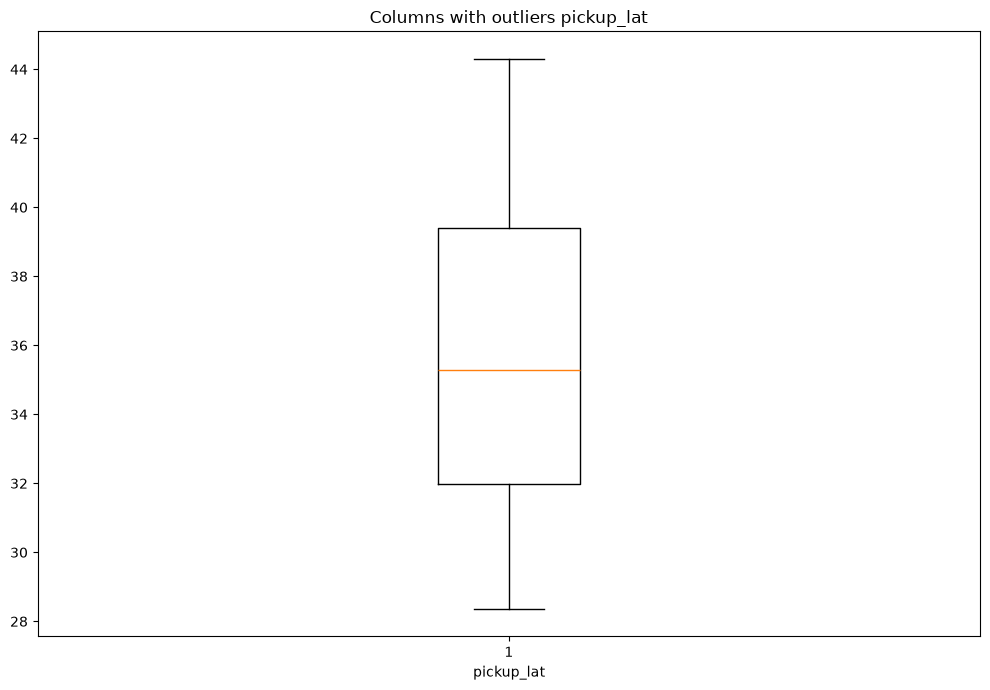

pickup_lon ---------->


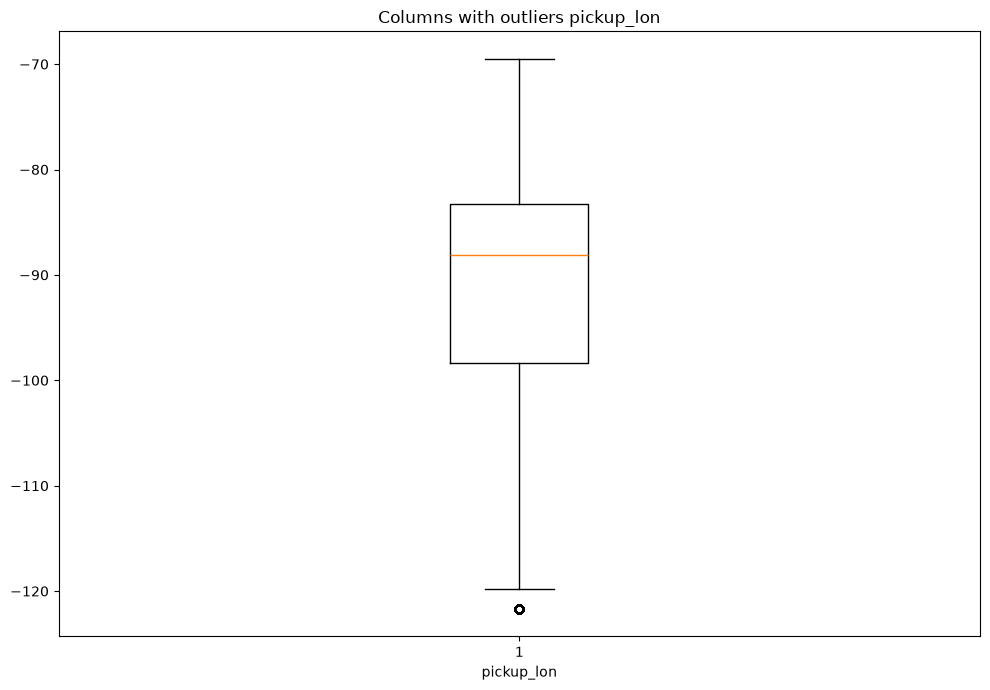

delivery_lat ---------->


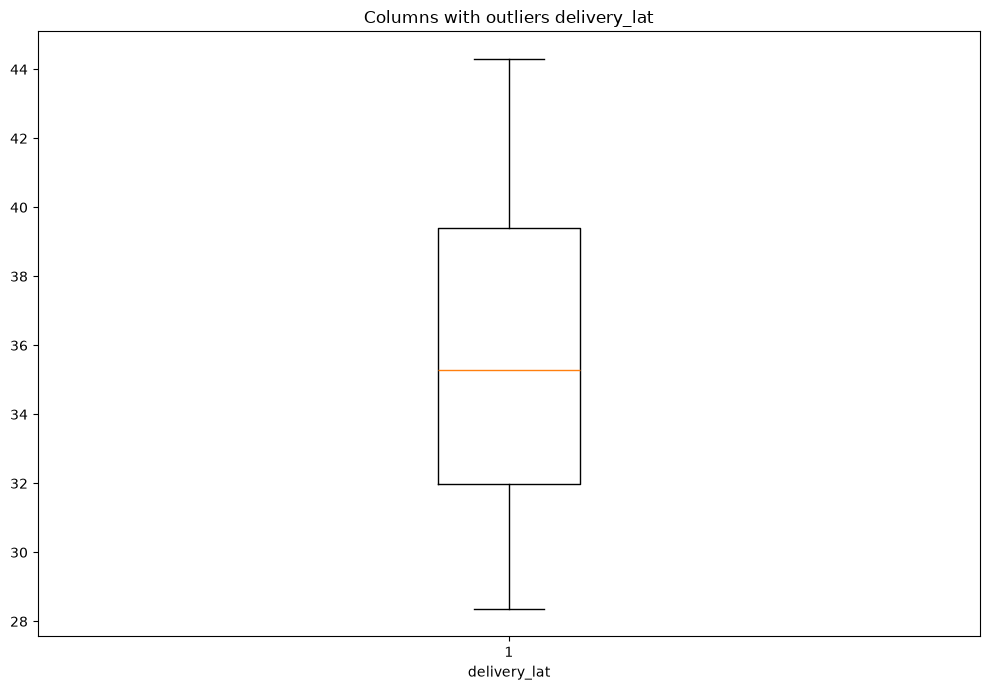

delivery_lon ---------->


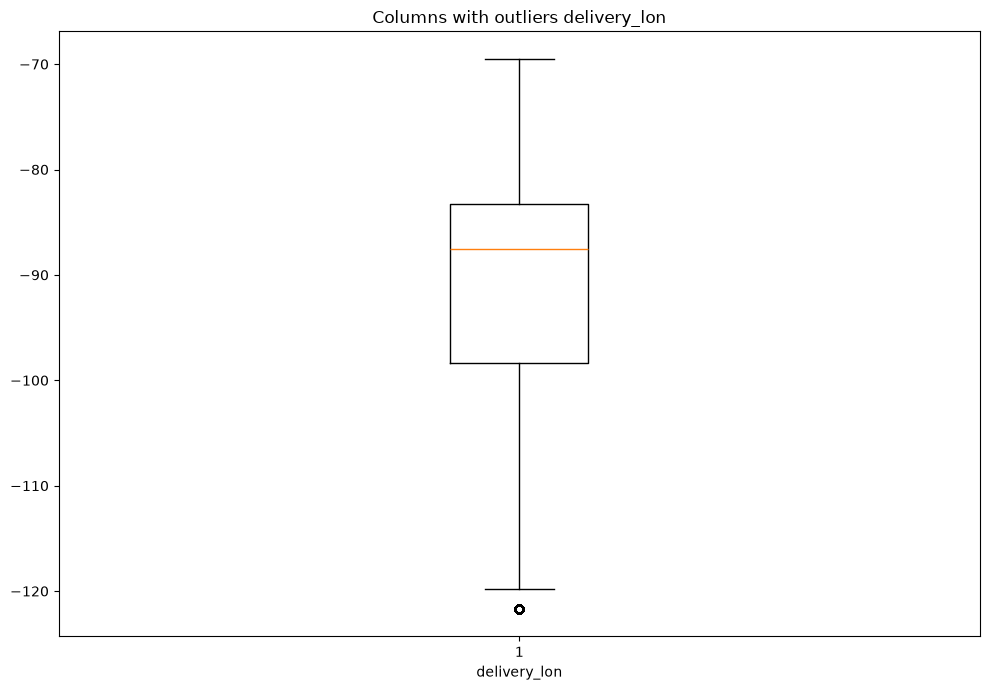

distance ---------->


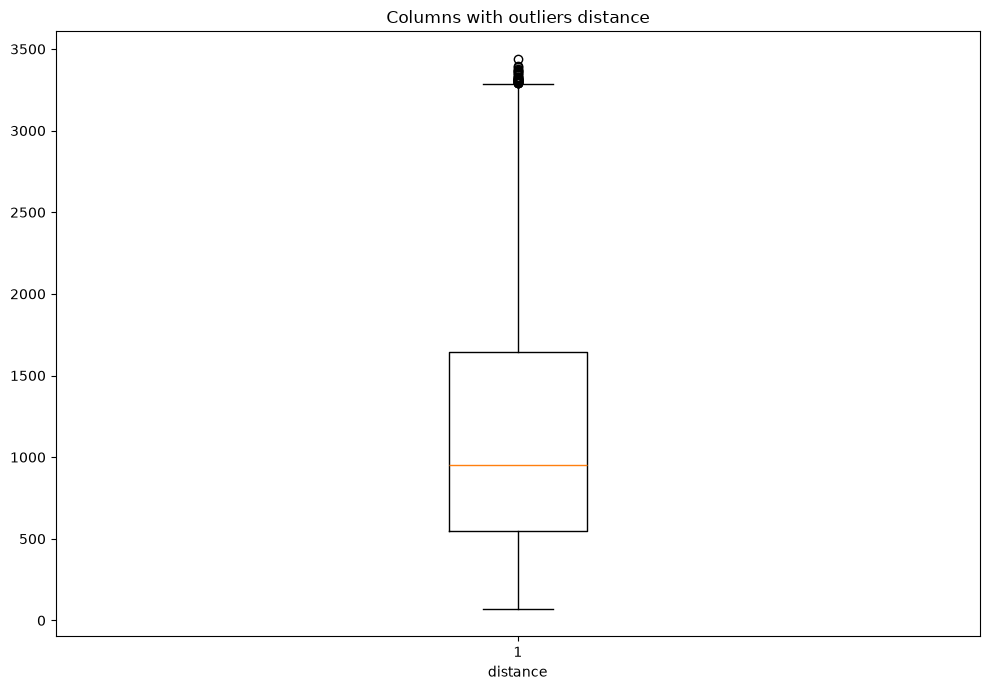

weight ---------->


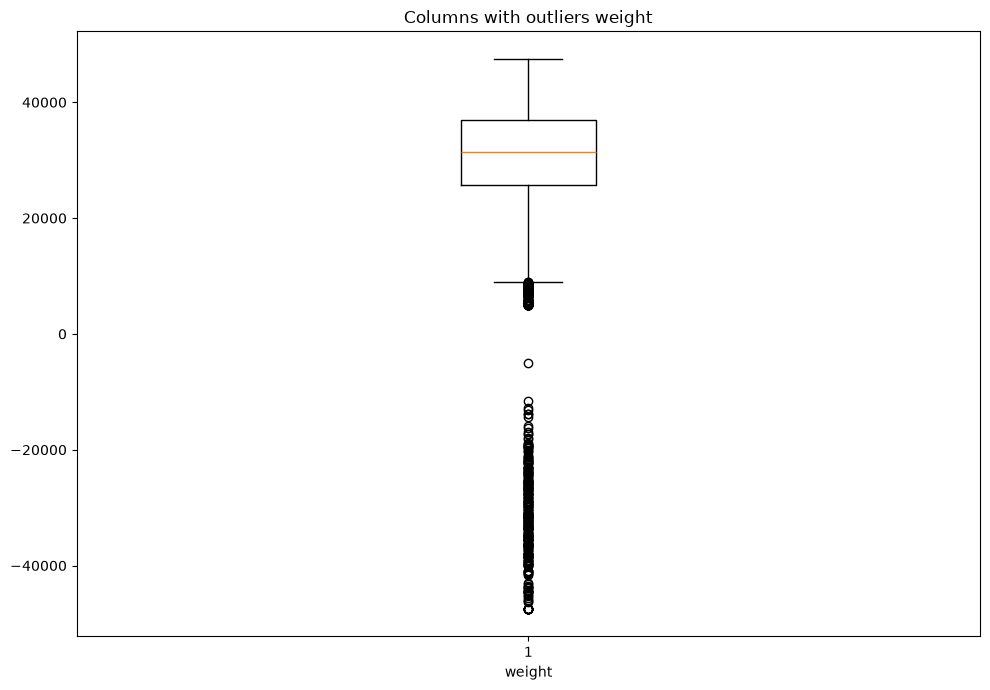

market_index ---------->


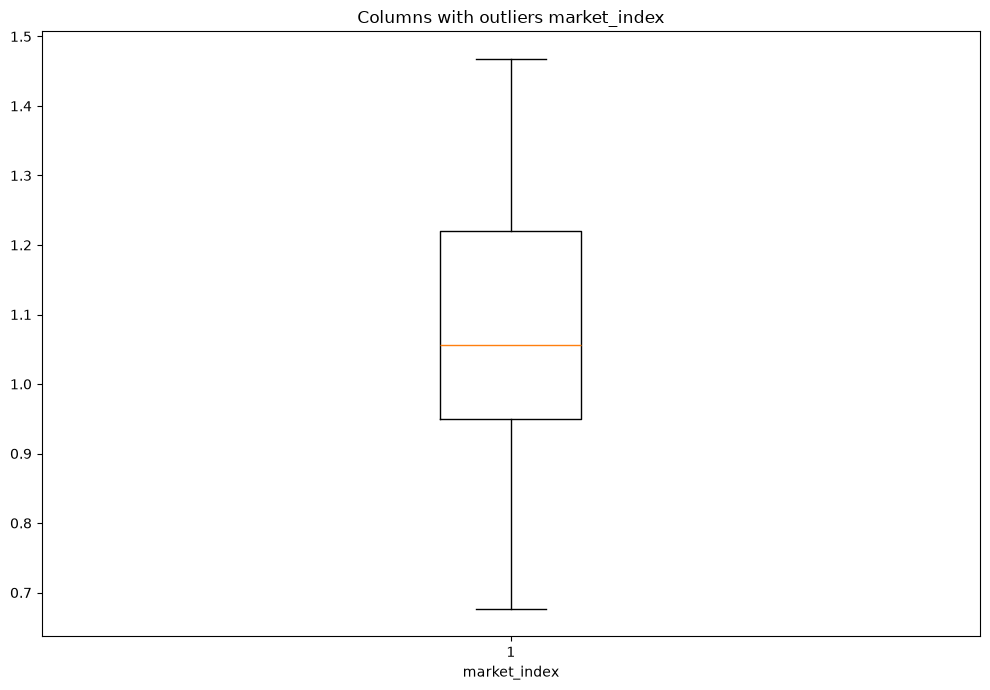

quote_signal ---------->


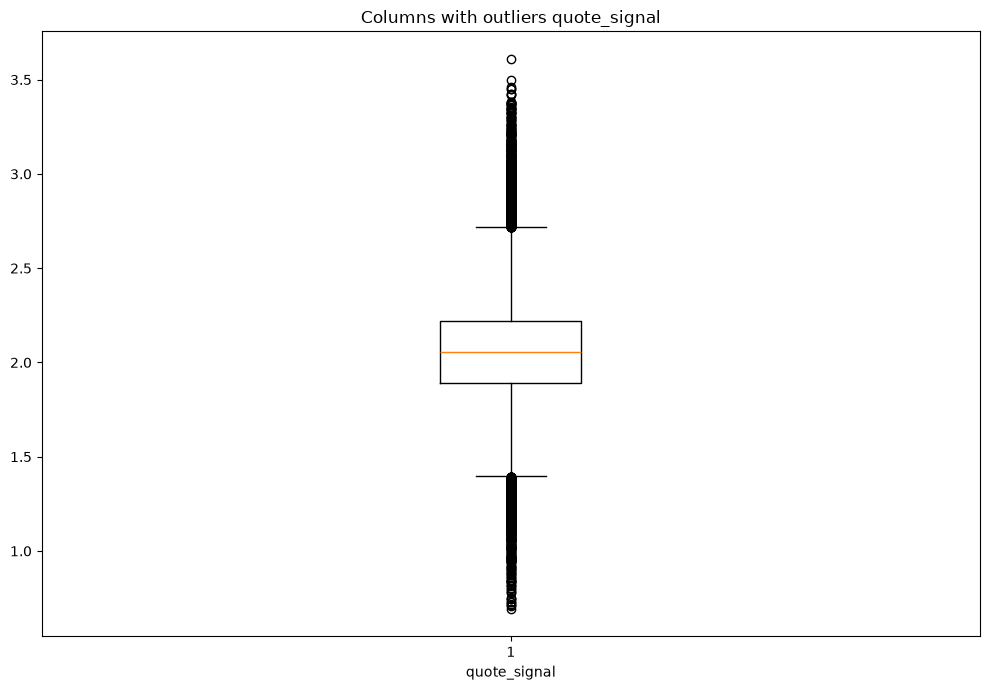

posted_rate ---------->


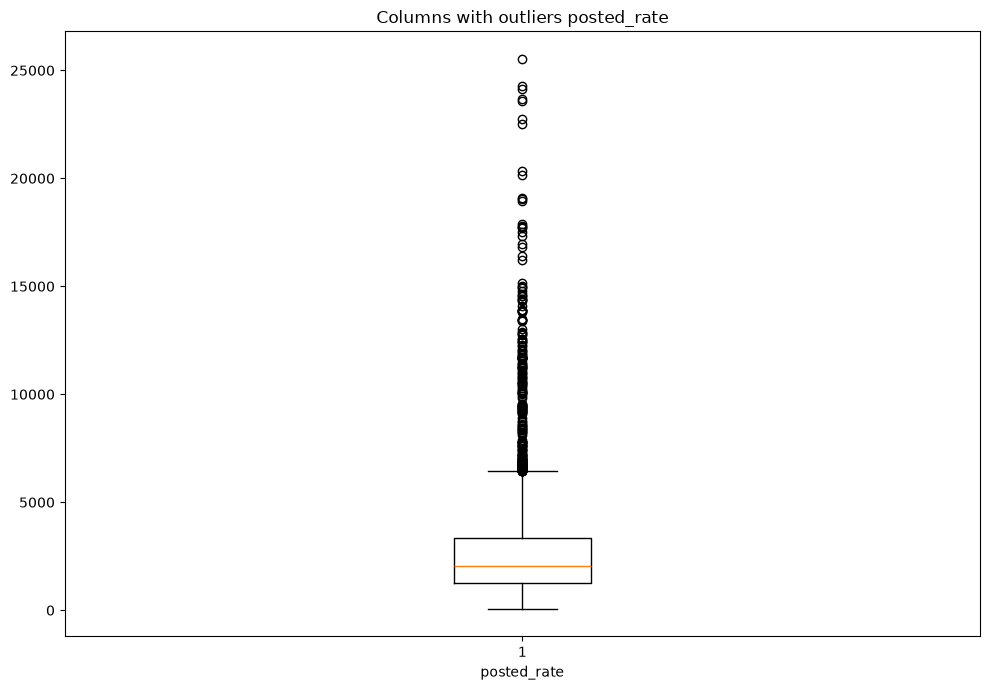

In [33]:
## Checking Outliers

for col in df.select_dtypes(include=['number']).columns:
    print(col + " ---------->")
    
    plt.figure(figsize=(10, 7))
    plt.boxplot(df[col].dropna())  

    plt.title(f"Columns with outliers {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Since outliers are calculated mathematically using the IQR method, the flagged points for quote_signal represent valid market variations rather than errors. Therefore, the weight column only requires a sign correction (converting negative values to positive using absolute values), while quote_signal can safely retain its natural range.

pickup_lat: Skewness = 0.2452 → Roughly Symmetric


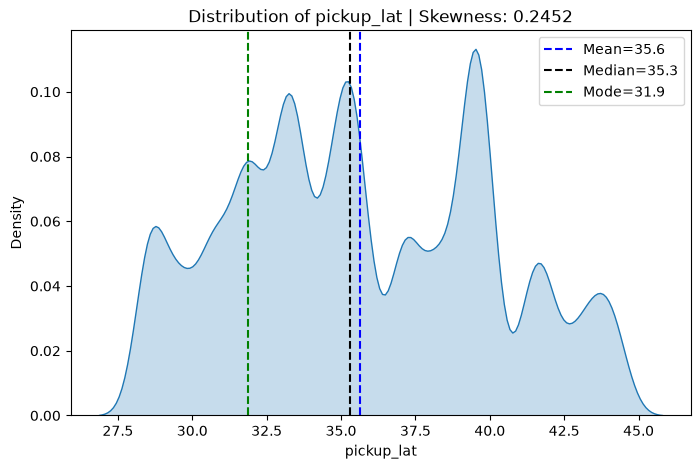

pickup_lon: Skewness = -0.6319 → Negatively Skewed


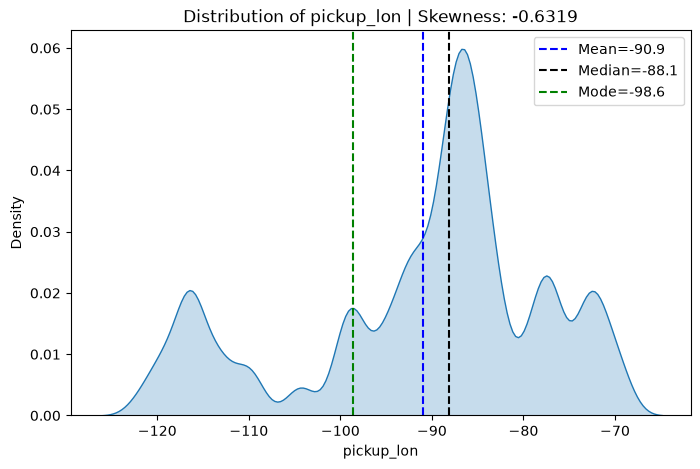

delivery_lat: Skewness = 0.2407 → Roughly Symmetric


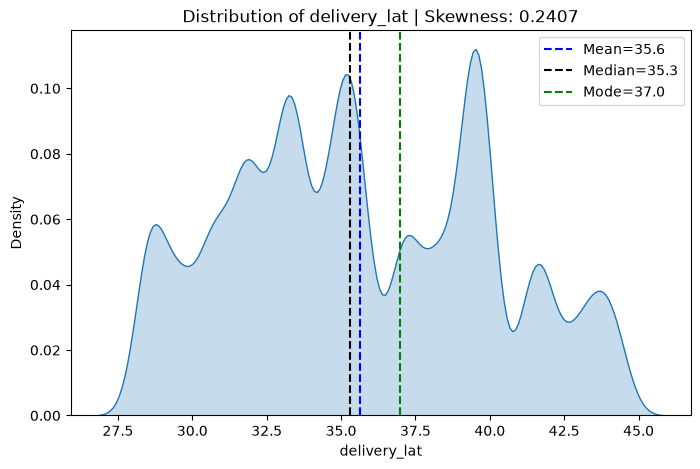

delivery_lon: Skewness = -0.7410 → Negatively Skewed


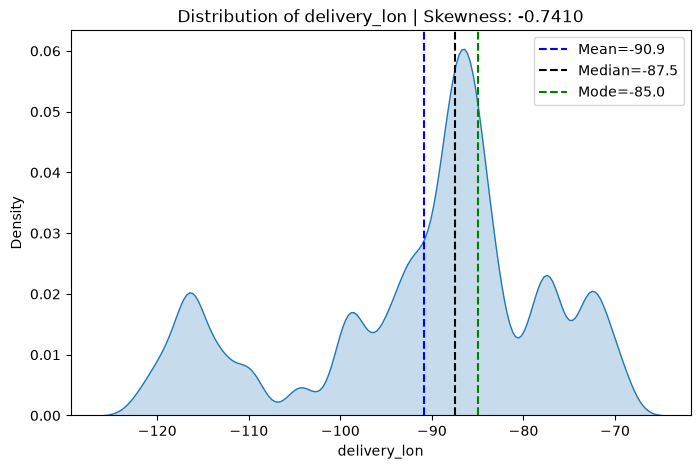

distance: Skewness = 0.7517 → Positively Skewed


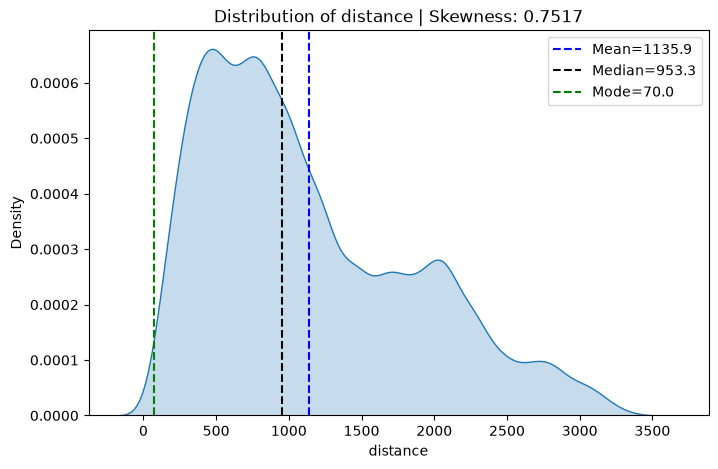

weight: Skewness = -0.1302 → Roughly Symmetric


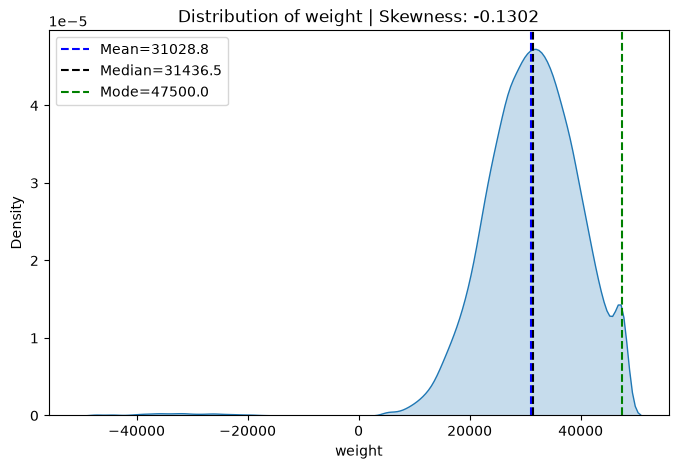

market_index: Skewness = 0.4924 → Roughly Symmetric


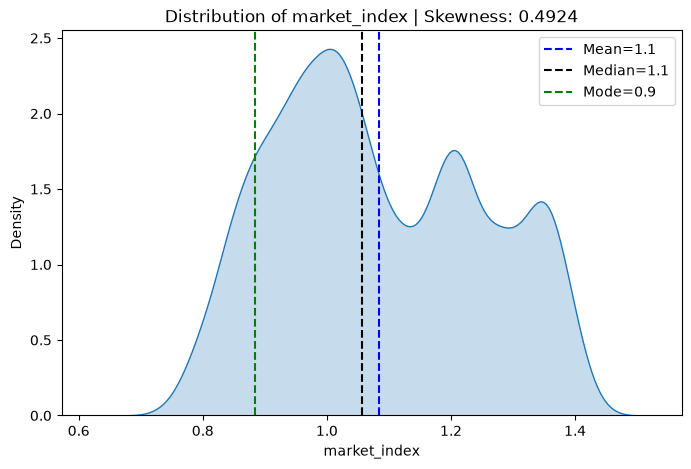

quote_signal: Skewness = 0.0692 → Roughly Symmetric


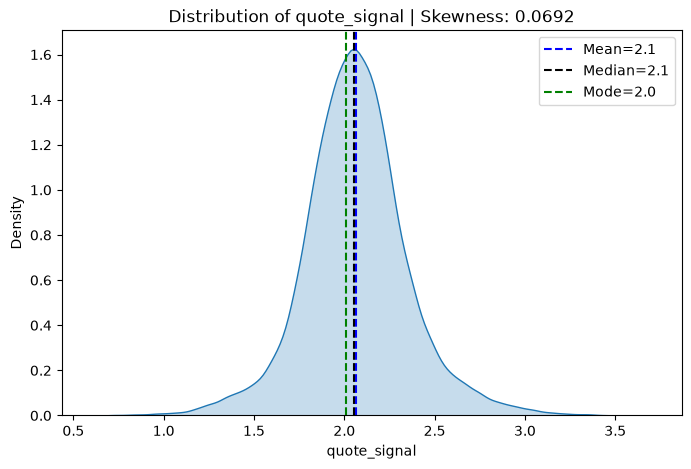

posted_rate: Skewness = 0.6927 → Positively Skewed


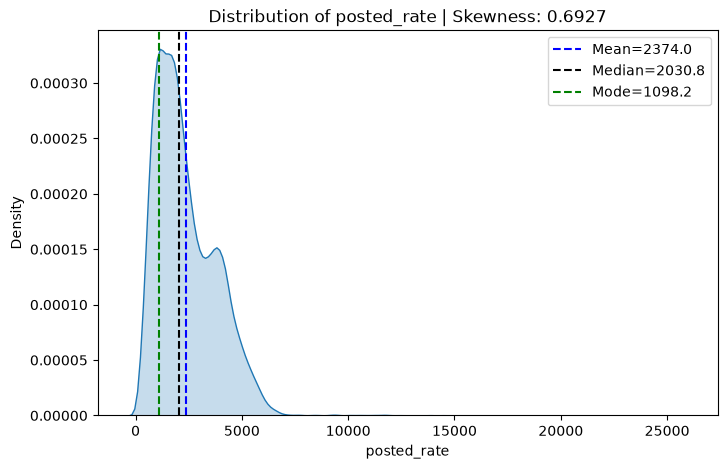

In [36]:
for col in df.select_dtypes(include=['number']).columns:
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    mode_val = df[col].mode()[0]

    pearson_skewness = (3 * (mean_val - median_val)) / std_val

    if pearson_skewness > 0.5:
        skew_type = "Positively Skewed"
    elif pearson_skewness < -0.5:
        skew_type = "Negatively Skewed"
    else:
        skew_type = "Roughly Symmetric"

    print(f"{col}: Skewness = {pearson_skewness:.4f} → {skew_type}")

    plt.figure(figsize=(8, 5))
    sns.kdeplot(df[col], fill=True)
    plt.axvline(mean_val, color='blue', linestyle='--', label=f"Mean={mean_val:.1f}")
    plt.axvline(median_val, color='black', linestyle='--', label=f"Median={median_val:.1f}")
    plt.axvline(mode_val, color='green', linestyle='--', label=f"Mode={mode_val:.1f}")
    plt.title(f"Distribution of {col} | Skewness: {pearson_skewness:.4f}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [37]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.head(5)

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.299988,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.500000,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.799988,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.400024,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.900024,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
